In [1]:
import sys
sys.path.insert(0, '/home/stavz/masters/gdc/APM')  # Add parent directory to path


In [ ]:

from pipeline.main import run_tad_annotation_only
import pandas as pd

genes = pd.read_csv("../test2/genes.csv") 
ccres = pd.read_csv("../test2/elem_focus.csv")
lncrnas_matched = pd.read_csv("../test2/lncrnas_matched.csv")

genes, ccres, lncrnas_matched = run_tad_annotation_only(
    genes, ccres, lncrnas_matched, 
    biosamples=["Golloshi_MDA231_bottom10", "Golloshi_MDA231_top10", "Golloshi_MDA231_control"]
)

In [14]:
pip install pyranges

Note: you may need to restart the kernel to use updated packages.


In [10]:
ccre_orig = pd.read_csv("../test2/ccres.csv")

In [11]:
ccre_orig

,chrom,start,end,cCRE_id,ENCODE_id,type,raw_type,center,MCF7,HMEC1
0,chr1,104896,105048,EH38D4327509,EH38E2776520,CTCF-only,"CTCF-only,CTCF-bound",104972,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
1,chr1,138866,139134,EH38D4327520,EH38E2776521,pELS,"pELS,CTCF-bound",139000,"{'in_MCF7': False, 'H3K27ac': None, 'H3K4me3':...","{'in_HMEC1': False, 'H3K27ac': None, 'H3K4me3'..."
2,chr1,181289,181639,EH38D4327525,EH38E2776524,DNase-H3K4me3,"DNase-H3K4me3,CTCF-bound",181464,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
3,chr1,267925,268171,EH38D4327544,EH38E2776528,CTCF-only,"CTCF-only,CTCF-bound",268048,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
4,chr1,586036,586264,EH38D4327554,EH38E2776532,CTCF-only,"CTCF-only,CTCF-bound",586150,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
...,...,...,...,...,...,...,...,...,...,...
1063873,chrY,21252996,21253278,EH38D6144481,EH38E3951203,dELS,dELS,21253137,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
1063874,chrY,21598449,21598656,EH38D6144550,EH38E3951229,CTCF-only,"CTCF-only,CTCF-bound",21598552,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
1063875,chrY,21839503,21839853,EH38D6144588,EH38E3951242,dELS,dELS,21839678,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."
1063876,chrY,26352857,26353207,EH38D4327371,EH38E3951251,pELS,pELS,26353032,"{'in_MCF7': True, 'H3K27ac': None, 'H3K4me3': ...","{'in_HMEC1': True, 'H3K27ac': None, 'H3K4me3':..."


In [ ]:
from pipeline.config import PATHS
import pandas as pd
import numpy as np

rna = pd.read_csv(PATHS.rna_expression, sep="\t", index_col=0)

# Check distributions
print("Value range:", rna.values.min(), "-", rna.values.max())
print("Any negative values?", (rna.values < 0).any())
print("Sample medians (first 10):", rna.median(axis=0).head(10))

# Check your APM genes are present
apm_genes = 
missing = [g for g in apm_genes if g not in rna.index]
print("Missing APM genes:", missing if missing else "None")

Value range: 0.0 - 20.9784
Any negative values? False
Sample medians (first 10): TCGA-AR-A5QQ-01    7.6017
TCGA-D8-A1JA-01    7.1889
TCGA-BH-A0BQ-01    7.7018
TCGA-BH-A0BT-01    7.4771
TCGA-A8-A06X-01    7.3657
TCGA-A8-A096-01    7.7069
TCGA-BH-A0C7-01    7.6811
TCGA-AC-A5XU-01    7.6858
TCGA-PE-A5DE-01    7.7095
TCGA-PE-A5DC-01    7.6997
dtype: float64
Missing APM genes: ['NECTIN2', 'NCR3LG1', 'B7-H6']


In [22]:
idx = rna.index.astype(str)

# 1) Look for the symbol anywhere in the row name
hits_symbol = idx[idx.str.contains("NCR3LG1", case=False, regex=False)]
print("Symbol hits:", hits_symbol[:10].tolist())

# 2) Look for Ensembl ID (most reliable)
hits_ensg = idx[idx.str.contains("ENSG00000188211", regex=False)]
print("ENSG hits:", hits_ensg[:10].tolist())

# 3) Look for B7-H6 variants (hyphen/no hyphen)
hits_b7 = idx[idx.str.upper().str.replace("-", "", regex=False).str.contains("B7H6")]
print("B7H6 hits:", hits_b7[:10].tolist())


Symbol hits: []
ENSG hits: []
B7H6 hits: []


In [24]:
immune_sub

,TCGA Study,Immune Subtype,TCGA Subtype,pathologic_stage,pathologic_T,pathologic_N,pathologic_M,PAM50_final,PAM50Call_RNAseq,PAM50_recomputed,...,T Cells gamma delta,TCR Evenness,TCR Richness,TCR Shannon,TGF-beta Response,TIL Regional Fraction,Th1 Cells,Th17 Cells,Th2 Cells,Wound Healing
TCGA Participant Barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-4H-AAAK,BRCA,C1,BRCA.LumA,Stage IIIA,T2,N2a,M0,LumA,NaN,LumA,...,0.0,0.989151,19.0,2.912494,0.7173,0.229580,-633.296078,777.948283,48.873581,-0.0490
TCGA-A1-A0SM,BRCA,C1,BRCA.LumA,Stage IIA,T2,N0 (i-),M0,LumA,LumA,Her2,...,0.0,NaN,1.0,0.000000,0.6972,2.264620,-407.748977,3328.837789,919.895731,-0.0325
TCGA-A2-A0CO,BRCA,C2,BRCA.LumA,Stage IIB,T3,N0,M0,LumA,NaN,LumA,...,0.0,0.975294,44.0,3.690696,0.4972,0.253570,380.358214,2325.114728,-332.434256,-0.2790
TCGA-A2-A0CQ,BRCA,C4,BRCA.LumA,Stage IA,T1,N0 (i-),M0,LumA,LumA,LumB,...,0.0,1.000000,12.0,2.484907,0.0635,1.317346,-1159.985350,1335.395101,553.020419,-0.0625
TCGA-A2-A0EU,BRCA,C1,BRCA.LumA,Stage IA,T1c,N0 (i-),M0,LumA,LumA,LumB,...,0.0,0.968393,6.0,1.735126,0.2129,1.295632,-750.462620,-2379.686581,592.676210,0.0595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-PE-A5DD,BRCA,C1,BRCA.LumA,Stage IIA,T2,N0,M0,LumB,NaN,LumB,...,0.0,0.950918,17.0,2.694154,0.4787,0.650684,-1105.513005,872.489833,-298.941787,-0.0740
TCGA-PL-A8LV,BRCA,C1,BRCA.Basal,Stage IIIB,T4,N0,M0,Basal,NaN,Basal,...,0.0,0.994172,33.0,3.476131,0.1897,NaN,-1069.900069,-125.497439,248.551054,0.1340
TCGA-S3-AA14,BRCA,C1,BRCA.LumA,Stage I,T1,N0 (i+),cM0 (i+),Her2,NaN,Her2,...,0.0,1.000000,8.0,2.079442,0.5820,NaN,-793.169515,986.138159,469.916751,-0.0525


In [1]:
import sys
sys.path.insert(0, '/home/stavz/masters/gdc/APM')  # Add parent directory to path

from pipeline.config import PATHS, PRIMARY_GENES, UCSC_RNA_SEQ_GENE_SYMBOL_CHANGE
import pandas as pd
import numpy as np
rna = pd.read_csv(PATHS.rna_expression, sep="\t")
rna.rename(columns={"sample": "gene"}, inplace=True)


rna[rna["gene"].isin(UCSC_RNA_SEQ_GENE_SYMBOL_CHANGE.keys())]

,gene,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AC-A5XU-01,TCGA-PE-A5DE-01,...,TCGA-A7-A13E-11,TCGA-C8-A8HP-01,TCGA-E9-A5FL-01,TCGA-AC-A2FB-11,TCGA-E2-A15F-01,TCGA-A2-A3XT-01,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-3C-AALJ-01,TCGA-B6-A0X1-01
9088,PVRL2,10.9959,12.2780,12.3053,13.1530,12.5690,11.6460,11.7529,10.8787,13.0289,...,10.9696,12.7465,10.8045,10.7371,12.9542,10.4318,12.3648,10.5015,13.4140,10.5721
12464,DKFZp686O24166,2.5772,4.2177,5.1320,3.7302,5.0995,5.4265,7.5020,6.5171,4.2300,...,5.1555,3.2490,3.3282,4.3816,6.9877,3.5159,7.1680,5.0761,4.3886,6.5200


In [ ]:
import sys
sys.path.insert(0, '/home/stavz/masters/gdc/APM')  # Add parent directory to path

import pandas as pd
from pipeline.config import PATHS, PRIMARY_GENES, UCSC_RNA_SEQ_GENE_SYMBOL_CHANGE
from pipeline.RNA_exp import normalize_expression_mat

rna = pd.read_csv(PATHS.rna_expression, sep="\t")
rna = normalize_expression_mat(rna)
immune_sub = pd.read_csv(PATHS.immune_subtype_annotations, sep="\t")

rna.set_index("gene", inplace=True)
immune_sub.set_index("TCGA Participant Barcode", inplace=True)


In [21]:
mapping = {
    sample: immune_sub.loc["-".join(sample.split("-")[:3]), "TCGA Subtype"]
    for sample in rna.columns if "-".join(sample.split("-")[:3]) in immune_sub.index and sample.split("-")[-1] == "01"
}

In [30]:
immune_sub["pathologic_T"]

TCGA Participant Barcode
TCGA-4H-AAAK     T2
TCGA-A1-A0SM     T2
TCGA-A2-A0CO     T3
TCGA-A2-A0CQ     T1
TCGA-A2-A0EU    T1c
               ... 
TCGA-PE-A5DD     T2
TCGA-PL-A8LV     T4
TCGA-S3-AA14     T1
TCGA-WT-AB41     T2
TCGA-Z7-A8R5     T3
Name: pathologic_T, Length: 1087, dtype: object

In [33]:
immune_sub["pathologic_M"].value_counts()

pathologic_M
M0          897
MX          162
M1           21
cM0 (i+)      6
Name: count, dtype: int64

Samples with PAM50 annotation: 1085/1218

PAM50 distribution:
pam50
BRCA.LumA      508
BRCA.LumB      191
BRCA.Basal     173
BRCA.Normal    139
BRCA.Her2       73
Name: count, dtype: int64

Top 10 centers:
center
BH    149
A2    102
E2     90
A8     79
D8     77
AR     68
E9     62
B6     58
C8     48
AO     47
Name: count, dtype: int64

Variance explained: PC1=11.7%, PC2=8.1%, PC3=6.4%


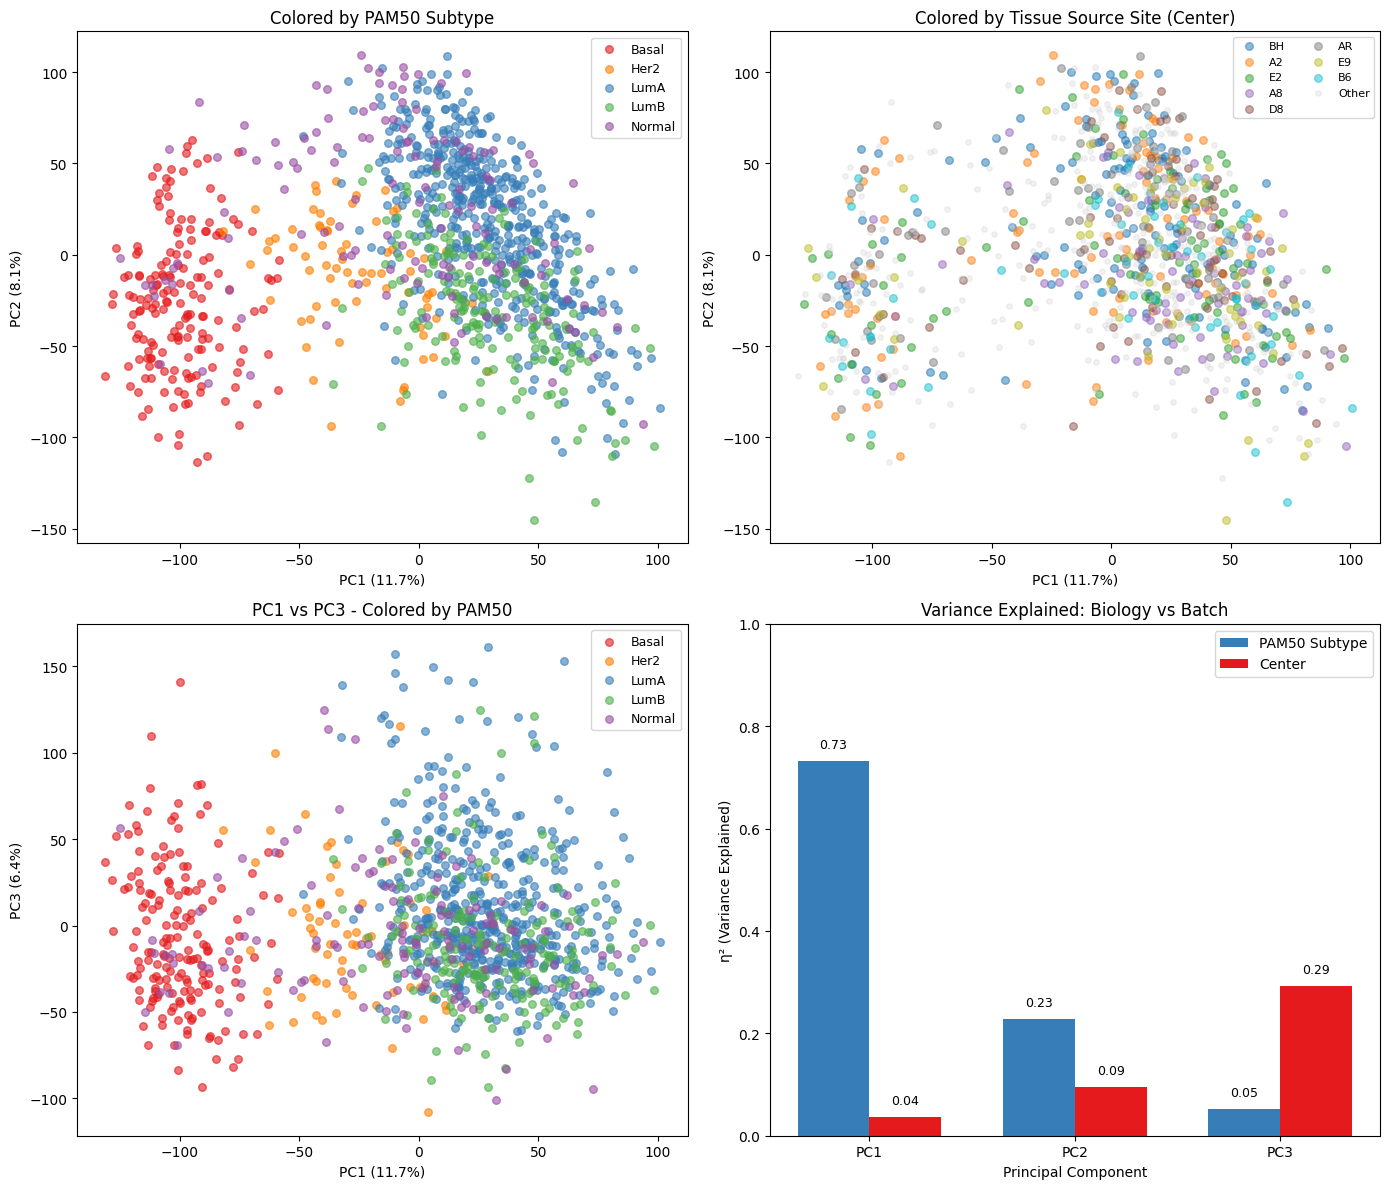


BATCH EFFECT ASSESSMENT SUMMARY

η² (variance explained) by factor:
PC     PAM50        Center       Ratio (PAM50/Center)
--------------------------------------------------
PC1    0.732        0.037        20.02               
PC2    0.228        0.095        2.40                
PC3    0.053        0.292        0.18                

--------------------------------------------------
⚠ VERDICT: Batch effects present. Consider ComBat with PAM50 as covariate.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Filter to samples that have PAM50 annotation
samples_with_pam50 = [s for s in rna.columns if s in mapping]
rna_filtered = rna[samples_with_pam50]

print(f"Samples with PAM50 annotation: {len(samples_with_pam50)}/{len(rna.columns)}")

# Extract center and PAM50 for each sample
sample_meta = pd.DataFrame({
    "sample": samples_with_pam50,
    "center": [s.split("-")[1] for s in samples_with_pam50],
    "pam50": [mapping[s] for s in samples_with_pam50]
})

print("\nPAM50 distribution:")
print(sample_meta["pam50"].value_counts())

print("\nTop 10 centers:")
print(sample_meta["center"].value_counts().head(10))

# PCA
pca = PCA(n_components=5)
expr_pca = pca.fit_transform(rna_filtered.T.values)

sample_meta["PC1"] = expr_pca[:, 0]
sample_meta["PC2"] = expr_pca[:, 1]
sample_meta["PC3"] = expr_pca[:, 2]

print(f"\nVariance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"PC3={pca.explained_variance_ratio_[2]:.1%}")

# Define colors
pam50_colors = {
    "BRCA.Basal": "#E41A1C",
    "BRCA.Her2": "#FF7F00",  
    "BRCA.LumA": "#377EB8",
    "BRCA.LumB": "#4DAF4A",
    "BRCA.Normal": "#984EA3"
}

top_centers = sample_meta["center"].value_counts().head(8).index.tolist()
center_colors = plt.cm.tab10(np.linspace(0, 1, len(top_centers)))
center_color_map = {c: center_colors[i] for i, c in enumerate(top_centers)}
center_color_map["Other"] = "lightgray"

sample_meta["center_plot"] = sample_meta["center"].apply(
    lambda x: x if x in top_centers else "Other"
)

# Create figure with 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top left: PC1 vs PC2, colored by PAM50
ax = axes[0, 0]
for subtype, color in pam50_colors.items():
    mask = sample_meta["pam50"] == subtype
    ax.scatter(
        sample_meta.loc[mask, "PC1"],
        sample_meta.loc[mask, "PC2"],
        c=color, label=subtype.replace("BRCA.", ""),
        alpha=0.6, s=30
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Colored by PAM50 Subtype")
ax.legend(loc="best", fontsize=9)

# Top right: PC1 vs PC2, colored by center
ax = axes[0, 1]
for center in top_centers + ["Other"]:
    mask = sample_meta["center_plot"] == center
    if not mask.any():
        continue
    ax.scatter(
        sample_meta.loc[mask, "PC1"],
        sample_meta.loc[mask, "PC2"],
        c=[center_color_map[center]], 
        label=center,
        alpha=0.5 if center != "Other" else 0.3,
        s=30 if center != "Other" else 15
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Colored by Tissue Source Site (Center)")
ax.legend(loc="best", fontsize=8, ncol=2)

# Bottom left: PC1 vs PC3, colored by PAM50
ax = axes[1, 0]
for subtype, color in pam50_colors.items():
    mask = sample_meta["pam50"] == subtype
    ax.scatter(
        sample_meta.loc[mask, "PC1"],
        sample_meta.loc[mask, "PC3"],
        c=color, label=subtype.replace("BRCA.", ""),
        alpha=0.6, s=30
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.set_title("PC1 vs PC3 - Colored by PAM50")
ax.legend(loc="best", fontsize=9)

# Bottom right: Quantitative assessment - variance explained by center vs PAM50
ax = axes[1, 1]

# Calculate R² for each PC vs center and PAM50
from sklearn.preprocessing import LabelEncoder

le_pam50 = LabelEncoder()
le_center = LabelEncoder()
pam50_encoded = le_pam50.fit_transform(sample_meta["pam50"])
center_encoded = le_center.fit_transform(sample_meta["center"])

# Eta-squared (like R² for categorical variables)
def eta_squared(pc_values, groups):
    """Proportion of variance explained by group membership"""
    grand_mean = pc_values.mean()
    ss_total = ((pc_values - grand_mean) ** 2).sum()
    
    group_means = pd.Series(pc_values).groupby(groups).transform("mean")
    ss_between = ((group_means - grand_mean) ** 2).sum()
    
    return ss_between / ss_total if ss_total > 0 else 0

pcs_to_check = ["PC1", "PC2", "PC3"]
eta_pam50 = [eta_squared(sample_meta[pc].values, sample_meta["pam50"].values) for pc in pcs_to_check]
eta_center = [eta_squared(sample_meta[pc].values, sample_meta["center"].values) for pc in pcs_to_check]

x = np.arange(len(pcs_to_check))
width = 0.35

bars1 = ax.bar(x - width/2, eta_pam50, width, label="PAM50 Subtype", color="#377EB8")
bars2 = ax.bar(x + width/2, eta_center, width, label="Center", color="#E41A1C")

ax.set_ylabel("η² (Variance Explained)")
ax.set_xlabel("Principal Component")
ax.set_title("Variance Explained: Biology vs Batch")
ax.set_xticks(x)
ax.set_xticklabels(pcs_to_check)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, val in zip(bars1, eta_pam50):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
for bar, val in zip(bars2, eta_center):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("pca_pam50_vs_center.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("BATCH EFFECT ASSESSMENT SUMMARY")
print("="*50)
print(f"\nη² (variance explained) by factor:")
print(f"{'PC':<6} {'PAM50':<12} {'Center':<12} {'Ratio (PAM50/Center)':<20}")
print("-"*50)
for i, pc in enumerate(pcs_to_check):
    ratio = eta_pam50[i] / eta_center[i] if eta_center[i] > 0 else float('inf')
    print(f"{pc:<6} {eta_pam50[i]:<12.3f} {eta_center[i]:<12.3f} {ratio:<20.2f}")

print("\n" + "-"*50)
if all(eta_pam50[i] > eta_center[i] * 2 for i in range(len(pcs_to_check))):
    print("✓ VERDICT: Biology dominates batch effects. ComBat likely NOT needed.")
elif any(eta_center[i] > eta_pam50[i] for i in range(len(pcs_to_check))):
    print("⚠ VERDICT: Batch effects present. Consider ComBat with PAM50 as covariate.")
else:
    print("~ VERDICT: Mixed signal. Inspect plots visually and consider downstream sensitivity analysis.")

In [26]:
apm_genes = PRIMARY_GENES
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(5)],
    index=rna_filtered.index
)

# Check APM gene loadings on PC3
apm_loadings = loadings.loc[[g for g in apm_genes if g in loadings.index], ["PC1", "PC2", "PC3"]]
apm_loadings["PC3_abs"] = apm_loadings["PC3"].abs()
print("APM gene loadings (sorted by |PC3|):")
print(apm_loadings.sort_values("PC3_abs", ascending=False))

# If APM genes have low PC3 loadings, batch effect won't impact your main analysis

APM gene loadings (sorted by |PC3|):
              PC1       PC2       PC3   PC3_abs
gene                                           
IL6ST    0.022754  0.018430 -0.033189  0.033189
NCR3LG1  0.008068  0.002696 -0.020091  0.020091
ADAM10   0.002529  0.005678 -0.017200  0.017200
EGFR    -0.022262  0.019203 -0.016402  0.016402
PSMB10  -0.005518  0.001277  0.015291  0.015291
...           ...       ...       ...       ...
PTPN2   -0.006633 -0.001418 -0.000615  0.000615
NLRC5   -0.010323  0.006800  0.000379  0.000379
PIAS3    0.002882  0.001583 -0.000244  0.000244
B2M     -0.005085  0.004753 -0.000194  0.000194
TAP2    -0.012580  0.001055  0.000103  0.000103

[66 rows x 4 columns]


In [14]:
from pipeline.CHIP.chip_loader import load_unified_chip
from pipeline.config import PATHS

chip = load_unified_chip(
    working_dir=PATHS.working_dir / "CHIP",
    output_path=PATHS.working_dir / "CHIP" / "unified_chip_peaks.parquet",
)

Loading ENCODE peaks from \home\stavz\masters\gdc\APM\data\CHIP\ENCODE ...
  Loaded ENCODE: CTCF_MCF7.bed (57,547 peaks)
  Loaded ENCODE: CTCF_T47D.bed (30,388 peaks)
Loading ChIP-Atlas peaks from \home\stavz\masters\gdc\APM\data\CHIP\CHIP_ATLAS ...
  Loaded CHIP_ATLAS: STAT1.bed (231 peaks)
  Loaded CHIP_ATLAS: STAT3.bed (1,308,570 peaks)


\\wsl.localhost\Ubuntu\home\stavz\masters\gdc\APM\pipeline\CHIP\chip_loader.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  unified = pd.concat([encode, chip_atlas], ignore_index=True)


  Dropped 4 rows with missing coordinates

Unified ChIP table: 1,396,732 peaks
  By source:
source
CHIP_ATLAS    1308799
ENCODE          87933
  Unique TFs: 3
  Unique cell types: 16
  Saved unified table to: \home\stavz\masters\gdc\APM\data\CHIP\unified_chip_peaks.parquet


In [ ]:
p

In [10]:
s = pd.read_csv("data/HiCHIP/TCGA_HiChIP_FitHiChIP_interactions_CNV_corrected_norm_counts.txt", sep="\t")

In [2]:
import os
os.chdir("..")

In [21]:
brca_samples = [col for col in s.columns if "BRCA" in col]
brca_samples

index_cols = s.columns[:6].tolist()
index_cols
display_cols = index_cols + brca_samples
s[display_cols].to_csv("tcga_brca_hichip.csv")

In [56]:
s = s[display_cols]


In [24]:
hichip_metadata = pd.read_csv("annotations/HiCHIP/TCGA_HiChIP_metadata.txt", sep="\t")

In [41]:
hichip_metadata["file_name"] = hichip_metadata["file_name"].str.replace("-","_")

In [46]:
hichip_metadata["data_format"].value_counts()
pattern = "|".join(brca_samples)

filtered = hichip_metadata[
    hichip_metadata["file_name"].str.contains(pattern, na=False)
]

In [49]:
len(filtered["case_submitter_id"].unique())

13

In [53]:
filtered = filtered[filtered["data_category"] == "significant interactions"]

In [62]:
filtered["file_name"].iloc[0]

'BRCA_08499A64_3FD8_4E62_AF08_3C66AF93CAE7_X004_S03_B1_T1_H3K27ac.FitHiChIP.interactions_Q0.1.bed'

In [63]:
rename_map = {
    sample_col: filtered.loc[
        filtered["file_name"].str.startswith(sample_col + ".", na=False),
        "case_submitter_id"
    ].dropna().iloc[0]
    for sample_col in brca_samples
    if filtered["file_name"].str.startswith(sample_col + ".", na=False).any()
}

s = s.rename(columns=rename_map)

In [3]:
s.to_csv("data/HiCHIP/TCGA_BRCA_PROCESSED.csv", index=False)

NameError: name 's' is not defined

In [4]:
import pandas as pd 
s = pd.read_csv("data/HiCHIP/TCGA_BRCA_PROCESSED.csv")
s.head()











,chr1,s1,e1,chr2,s2,e2,TCGA-A7-A0CH,TCGA-AR-A0TV,TCGA-AO-A0JG,TCGA-AO-A03L,TCGA-C8-A133,TCGA-BH-A0E0,TCGA-A2-A0EY,TCGA-BH-A0EE,TCGA-A2-A0YJ,TCGA-C8-A12M,TCGA-S3-AA0Z,TCGA-AO-A124,TCGA-A2-A0T5
0,chr1,770000,780000,chr1,820000,830000,9.159381,5.657424,2.316766,3.620740,7.211708,5.207503,3.761769,7.224659,6.571574,8.394474,3.317556,4.908921,3.270144
1,chr1,770000,780000,chr1,850000,860000,1.665342,0.628603,2.316766,0.905185,7.211708,2.231787,1.074791,1.699920,1.408194,0.645729,2.211704,1.888047,0.000000
2,chr1,770000,780000,chr1,910000,920000,0.832671,2.514411,0.000000,2.715555,1.030244,0.000000,1.074791,0.424980,0.469398,0.645729,1.105852,2.643265,3.270144
3,chr1,770000,780000,chr1,960000,970000,0.000000,1.257205,0.000000,0.905185,1.030244,0.743929,0.000000,1.274940,0.469398,0.645729,0.276463,0.755219,0.000000
4,chr1,770000,780000,chr1,1010000,1020000,1.665342,0.000000,0.000000,2.715555,0.000000,0.000000,0.537396,2.124900,2.346991,0.645729,0.829389,0.377609,0.000000


In [1]:
import pandas as pd
from config import PATHS
# d = pd.read_parquet(PATHS.chip_unified)

In [7]:
d

,chrom,start,end,tf,cell_type,source,score_norm
0,chr1,114346345,114346951,CTCF,MCF-7,ENCODE,831.37613
1,chr17,58587526,58588116,CTCF,MCF-7,ENCODE,727.04384
2,chr20,58209692,58210326,CTCF,MCF-7,ENCODE,712.01997
3,chr17,57243011,57243613,CTCF,MCF-7,ENCODE,679.74922
4,chr20,48657609,48658182,CTCF,MCF-7,ENCODE,660.03573
...,...,...,...,...,...,...,...
1396727,chrY,56883697,56883906,STAT3,T-47D,CHIP_ATLAS,NaN
1396728,chrY,56883701,56883953,STAT3,HCC1143,CHIP_ATLAS,NaN
1396729,chrY,56883704,56883953,STAT3,MCF-7,CHIP_ATLAS,NaN
1396730,chrY,56883723,56883908,STAT3,T-47D,CHIP_ATLAS,NaN


In [3]:
clin = pd.read_csv(PATHS.brca_clinical, sep="\t")

In [10]:
clin

,sampleID,AJCC_Stage_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,CN_Clusters_nature2012,Converted_Stage_nature2012,Days_to_Date_of_Last_Contact_nature2012,Days_to_date_of_Death_nature2012,ER_Status_nature2012,Gender_nature2012,HER2_Final_Status_nature2012,...,_GENOMIC_ID_TCGA_BRCA_mutation_wustl_gene,_GENOMIC_ID_TCGA_BRCA_miRNA_GA,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_percentile,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_GA_gene,_GENOMIC_ID_TCGA_BRCA_gistic2thd,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_HiSeq_gene,_GENOMIC_ID_TCGA_BRCA_G4502A_07_3,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2,_GENOMIC_ID_TCGA_BRCA_gistic2,_GENOMIC_ID_TCGA_BRCA_PDMarray
0,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6ef883fc-81f3-4089-95e0-86904ffc0d38,NaN,TCGA-3C-AAAU-01A-11D-A41E-01,TCGA-3C-AAAU-01,NaN,6ef883fc-81f3-4089-95e0-86904ffc0d38,TCGA-3C-AAAU-01A-11D-A41E-01,NaN
1,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,NaN,TCGA-3C-AALI-01A-11D-A41E-01,TCGA-3C-AALI-01,NaN,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,TCGA-3C-AALI-01A-11D-A41E-01,NaN
2,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,c924c2a8-ab41-4499-bb30-79705cc17d45,NaN,TCGA-3C-AALJ-01A-31D-A41E-01,TCGA-3C-AALJ-01,NaN,c924c2a8-ab41-4499-bb30-79705cc17d45,TCGA-3C-AALJ-01A-31D-A41E-01,NaN
3,TCGA-3C-AALK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1a19e068-d213-41ef-aebb-104017a883cc,NaN,TCGA-3C-AALK-01A-11D-A41E-01,TCGA-3C-AALK-01,NaN,1a19e068-d213-41ef-aebb-104017a883cc,TCGA-3C-AALK-01A-11D-A41E-01,NaN
4,TCGA-4H-AAAK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2ea9e472-a408-4ae0-975d-50a566f22b2a,NaN,TCGA-4H-AAAK-01A-12D-A41E-01,TCGA-4H-AAAK-01,NaN,2ea9e472-a408-4ae0-975d-50a566f22b2a,TCGA-4H-AAAK-01A-12D-A41E-01,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1242,TCGA-XX-A899-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8e339298-3e3c-4b31-96a9-a842e973e583,NaN,TCGA-XX-A899-01A-11D-A36I-01,TCGA-XX-A899-01,NaN,8e339298-3e3c-4b31-96a9-a842e973e583,TCGA-XX-A899-01A-11D-A36I-01,NaN
1243,TCGA-XX-A899-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1244,TCGA-XX-A89A-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,501a70d8-3932-49c0-aa13-774756fb89e3,NaN,TCGA-XX-A89A-01A-11D-A36I-01,TCGA-XX-A89A-01,NaN,501a70d8-3932-49c0-aa13-774756fb89e3,TCGA-XX-A89A-01A-11D-A36I-01,NaN
1245,TCGA-Z7-A8R5-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,43c6d23b-2fcd-499e-82ef-10f15d8ede90,NaN,TCGA-Z7-A8R5-01A-42D-A41E-01,TCGA-Z7-A8R5-01,NaN,43c6d23b-2fcd-499e-82ef-10f15d8ede90,TCGA-Z7-A8R5-01A-42D-A41E-01,NaN


In [8]:
imm = pd.read_csv(PATHS.immune_subtype_annotations, sep="\t")

In [9]:
imm

,sample_id,PAM50_recomputed,PAM50Call_RNAseq,PAM50_final,thornsson_subtype,CPE
0,TCGA-3C-AAAU-01,LumB,NaN,LumB,NaN,0.7886
1,TCGA-3C-AALI-01,Her2,NaN,Her2,NaN,0.6974
2,TCGA-3C-AALJ-01,LumB,NaN,LumB,NaN,0.7666
3,TCGA-3C-AALK-01,LumA,NaN,LumA,NaN,0.6869
4,TCGA-4H-AAAK-01,LumA,NaN,LumA,NaN,0.6490
...,...,...,...,...,...,...
1213,TCGA-WT-AB44-01,LumA,NaN,LumA,NaN,0.7493
1214,TCGA-XX-A899-01,LumA,NaN,LumA,NaN,0.6069
1215,TCGA-XX-A89A-01,LumA,NaN,LumA,NaN,0.6067
1216,TCGA-Z7-A8R5-01,Normal,NaN,Normal,NaN,0.6919


In [11]:
hla = pd.read_csv(PATHS.hla_types_tsv, sep="\t")

AttributeError: 'PathConfig' object has no attribute 'hla_types_tsv'

In [2]:
mir = pd.read_csv(PATHS.mirna_expression_tsv, sep="\t")

In [3]:
mir

,miRNA_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A1HI-01A,TCGA-A7-A0CD-01A,TCGA-5L-AAT1-01A,TCGA-BH-A0C0-01A,TCGA-B6-A1KC-01B,TCGA-PL-A8LV-01A,TCGA-GM-A2DO-01A,...,TCGA-A2-A4RW-01A,TCGA-BH-A0HA-11A,TCGA-E2-A572-01A,TCGA-BH-A0BS-11A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-E9-A1NA-11A,TCGA-A1-A0SB-01A,TCGA-AQ-A7U7-01A,TCGA-AR-A24M-01A
0,hsa-let-7a-1,12.815167,12.968838,13.263951,12.871879,13.865815,12.548033,13.854649,13.055348,14.386116,...,12.247994,14.963895,13.982113,14.503116,13.498005,13.164728,13.546746,14.030370,12.595282,13.354509
1,hsa-let-7a-2,12.816051,12.972606,13.247779,12.870939,13.861453,12.524701,13.860289,13.046915,14.394687,...,12.249885,14.967838,13.983264,14.508651,13.484103,13.171852,13.554419,14.033059,12.596542,13.370006
2,hsa-let-7a-3,12.855016,12.972485,13.270085,12.896584,13.867042,12.546562,13.871269,13.068890,14.398910,...,12.263586,14.962892,13.994772,14.514271,13.506195,13.179930,13.552386,14.044442,12.609535,13.364077
3,hsa-let-7b,14.730158,14.497080,13.844852,14.935364,14.606950,14.476057,15.285572,13.071202,14.004710,...,12.376184,15.862450,14.322531,16.035167,14.652597,16.036739,15.512574,16.502933,13.483368,15.476751
4,hsa-let-7c,11.169628,11.869264,10.904361,9.644680,11.237808,9.295809,8.990267,10.136929,10.492184,...,10.417513,13.613759,11.344678,13.568041,10.709519,11.185896,13.291578,13.396463,11.299802,11.084530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,hsa-mir-9500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1877,hsa-mir-96,5.207594,4.107026,4.245085,4.177824,4.828995,4.022325,4.116569,6.724416,5.462970,...,5.928751,2.356555,5.358781,1.452255,7.013319,4.797963,2.414908,5.599551,4.049405,4.182526
1878,hsa-mir-98,4.813624,5.935319,6.387204,3.902867,5.937946,6.801663,5.989257,5.700251,6.635294,...,5.787135,5.260105,5.998016,5.101735,5.891110,4.675002,5.172197,6.007131,5.772411,5.218093
1879,hsa-mir-99a,9.771403,10.522932,9.381787,7.396593,9.276247,7.325148,8.016058,8.161315,8.258518,...,8.141366,12.372663,9.207484,12.214745,9.147799,9.678047,11.550806,12.010321,10.086468,9.619212


In [6]:
tarbase = pd.read_csv(PATHS.mirtarbase_csv)

In [22]:
tarbase[tarbase["miRNA"].str.contains("1180")]

,miRTarBase ID,miRNA,Species (miRNA),Target Gene,Target Gene (Entrez ID),Species (Target Gene),Experiments,Support Type,References (PMID)
43732,MIRT035956,hsa-miR-1180-3p,hsa,ZCCHC14,23174.0,hsa,CLASH,Functional MTI (Weak),23622248.0
43733,MIRT035955,hsa-miR-1180-3p,hsa,POLR2I,5438.0,hsa,CLASH,Functional MTI (Weak),23622248.0
43734,MIRT035954,hsa-miR-1180-3p,hsa,SRSF4,6429.0,hsa,CLASH,Functional MTI (Weak),23622248.0
43735,MIRT035953,hsa-miR-1180-3p,hsa,ACTG1,71.0,hsa,CLASH,Functional MTI (Weak),23622248.0
43736,MIRT035951,hsa-miR-1180-3p,hsa,ND5,4540.0,hsa,CLASH,Functional MTI (Weak),23622248.0
...,...,...,...,...,...,...,...,...,...
3984007,MIRT2662929,hsa-miR-1180,hsa,WNT8B,7479.0,hsa,CLIP-seq,Functional MTI (Weak),NaN
3987808,MIRT2664951,hsa-miR-1180,hsa,ZBTB38,253461.0,hsa,CLIP-seq,Functional MTI (Weak),NaN
3992774,MIRT2375037,hsa-miR-1180,hsa,ZMIZ1,57178.0,hsa,CLIP-seq,Functional MTI (Weak),NaN
3995857,MIRT1521770,hsa-miR-1180,hsa,ZNF317,57693.0,hsa,CLIP-seq,Functional MTI (Weak),NaN


In [17]:
mir[mir["miRNA_ID"] == "hsa-mir-1180"]

,miRNA_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A1HI-01A,TCGA-A7-A0CD-01A,TCGA-5L-AAT1-01A,TCGA-BH-A0C0-01A,TCGA-B6-A1KC-01B,TCGA-PL-A8LV-01A,TCGA-GM-A2DO-01A,...,TCGA-A2-A4RW-01A,TCGA-BH-A0HA-11A,TCGA-E2-A572-01A,TCGA-BH-A0BS-11A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-E9-A1NA-11A,TCGA-A1-A0SB-01A,TCGA-AQ-A7U7-01A,TCGA-AR-A24M-01A
29,hsa-mir-1180,2.437014,1.598847,1.99775,0.431842,4.591354,3.343367,6.172069,3.706995,5.404846,...,2.215705,1.717956,3.943962,2.269027,4.353965,2.471312,3.439277,2.83912,3.990792,2.748311


In [19]:
mir[mir["miRNA_ID"] == "hsa-mir-1180"]

,miRNA_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A1HI-01A,TCGA-A7-A0CD-01A,TCGA-5L-AAT1-01A,TCGA-BH-A0C0-01A,TCGA-B6-A1KC-01B,TCGA-PL-A8LV-01A,TCGA-GM-A2DO-01A,...,TCGA-A2-A4RW-01A,TCGA-BH-A0HA-11A,TCGA-E2-A572-01A,TCGA-BH-A0BS-11A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-E9-A1NA-11A,TCGA-A1-A0SB-01A,TCGA-AQ-A7U7-01A,TCGA-AR-A24M-01A
29,hsa-mir-1180,2.437014,1.598847,1.99775,0.431842,4.591354,3.343367,6.172069,3.706995,5.404846,...,2.215705,1.717956,3.943962,2.269027,4.353965,2.471312,3.439277,2.83912,3.990792,2.748311


In [24]:
mir.head(100)

,miRNA_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A1HI-01A,TCGA-A7-A0CD-01A,TCGA-5L-AAT1-01A,TCGA-BH-A0C0-01A,TCGA-B6-A1KC-01B,TCGA-PL-A8LV-01A,TCGA-GM-A2DO-01A,...,TCGA-A2-A4RW-01A,TCGA-BH-A0HA-11A,TCGA-E2-A572-01A,TCGA-BH-A0BS-11A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-E9-A1NA-11A,TCGA-A1-A0SB-01A,TCGA-AQ-A7U7-01A,TCGA-AR-A24M-01A
0,hsa-let-7a-1,12.815167,12.968838,13.263951,12.871879,13.865815,12.548033,13.854649,13.055348,14.386116,...,12.247994,14.963895,13.982113,14.503116,13.498005,13.164728,13.546746,14.030370,12.595282,13.354509
1,hsa-let-7a-2,12.816051,12.972606,13.247779,12.870939,13.861453,12.524701,13.860289,13.046915,14.394687,...,12.249885,14.967838,13.983264,14.508651,13.484103,13.171852,13.554419,14.033059,12.596542,13.370006
2,hsa-let-7a-3,12.855016,12.972485,13.270085,12.896584,13.867042,12.546562,13.871269,13.068890,14.398910,...,12.263586,14.962892,13.994772,14.514271,13.506195,13.179930,13.552386,14.044442,12.609535,13.364077
3,hsa-let-7b,14.730158,14.497080,13.844852,14.935364,14.606950,14.476057,15.285572,13.071202,14.004710,...,12.376184,15.862450,14.322531,16.035167,14.652597,16.036739,15.512574,16.502933,13.483368,15.476751
4,hsa-let-7c,11.169628,11.869264,10.904361,9.644680,11.237808,9.295809,8.990267,10.136929,10.492184,...,10.417513,13.613759,11.344678,13.568041,10.709519,11.185896,13.291578,13.396463,11.299802,11.084530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,hsa-mir-1261,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
96,hsa-mir-1262,0.000000,0.745312,0.806070,0.000000,0.465585,0.000000,0.000000,0.000000,0.000000,...,0.751423,2.538133,0.244270,2.044547,0.913836,1.241012,1.125445,0.910276,0.480810,0.277183
97,hsa-mir-1263,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
98,hsa-mir-1264,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.244270,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [29]:
mir = pd.read_csv("data/miRNA/XENA_mirna_arm_specific.tsv", sep="\t")

In [31]:
gencode_gtf_pq = pd.read_parquet(PATHS.gencode_gtf_pq)

In [34]:
gencode_gtf_pq[gencode_gtf_pq["gene_name"] == "BRCA1"]

,seqname,source,feature,start,end,score,strand,frame,gene_id,gene_name,gene_type,transcript_id,transcript_name,transcript_type,tag_list,tag,is_MANE
6276671,chr17,HAVANA,gene,43044292,43170245,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,None,None,None,[overlapping_locus],overlapping_locus,False
6276672,chr17,HAVANA,transcript,43044292,43125476,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000921914.1,BRCA1-243,protein_coding,"[basic, TAGENE, CCDS]",basic|TAGENE|CCDS,False
6276673,chr17,HAVANA,exon,43125271,43125476,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000921914.1,BRCA1-243,protein_coding,"[basic, TAGENE, CCDS]",basic|TAGENE|CCDS,False
6276674,chr17,HAVANA,exon,43124017,43124115,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000921914.1,BRCA1-243,protein_coding,"[basic, TAGENE, CCDS]",basic|TAGENE|CCDS,False
6276675,chr17,HAVANA,CDS,43124017,43124096,.,-,0,ENSG00000012048.27,BRCA1,protein_coding,ENST00000921914.1,BRCA1-243,protein_coding,"[basic, TAGENE, CCDS]",basic|TAGENE|CCDS,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6278405,chr17,HAVANA,exon,43114391,43114633,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000700185.1,BRCA1-239,protein_coding_CDS_not_defined,[RNA_Seq_supported_only],RNA_Seq_supported_only,False
6278406,chr17,HAVANA,transcript,43122343,43125370,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000700186.1,BRCA1-240,protein_coding_CDS_not_defined,[],,False
6278407,chr17,HAVANA,exon,43125271,43125370,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000700186.1,BRCA1-240,protein_coding_CDS_not_defined,[],,False
6278408,chr17,HAVANA,exon,43124017,43124115,.,-,.,ENSG00000012048.27,BRCA1,protein_coding,ENST00000700186.1,BRCA1-240,protein_coding_CDS_not_defined,[],,False


In [3]:
import pandas as pd
rna = pd.read_csv("data/RNAexp_TCGA/TCGA-BRCA.star_tpm_processed.tsv", sep="\t")
rna_raw = pd.read_csv("data/RNAexp_TCGA/TCGA-BRCA.star_tpm_mapped.tsv", sep="\t")

In [2]:
import os
os.chdir("..")

In [5]:
rna_raw

,gene_symbol,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,TSPAN6,ENSG00000000003.15,5.662037,3.703721,6.514515,4.784917,4.251984,3.536849,4.645690,6.021755,...,4.825501,4.142806,4.960919,4.770121,5.276757,6.436490,6.184500,2.670931,6.834395,3.650719
1,TNMD,ENSG00000000005.6,3.376096,0.463099,0.000000,2.328061,0.435415,0.736475,1.255622,0.392647,...,0.134747,0.159500,0.079566,3.312418,0.000000,0.383608,0.755144,0.479644,0.526069,0.059909
2,DPM1,ENSG00000000419.13,6.860140,7.086452,6.805072,6.443071,6.178436,6.823355,5.749910,6.977449,...,6.382933,6.436308,6.994589,6.005000,7.382161,7.220846,6.868277,7.033110,6.384368,8.153019
3,SCYL3,ENSG00000000457.14,4.400552,4.051007,5.037264,4.374970,3.558464,2.108324,4.487107,4.021000,...,3.891448,3.765057,4.946796,3.648707,3.664915,3.752192,4.093078,4.831796,4.368028,4.172247
4,C1orf112,ENSG00000000460.17,2.845169,2.426989,4.043248,4.162790,2.589548,2.277777,2.545178,3.372492,...,2.557655,2.566596,3.746915,2.494160,3.104957,3.111549,2.538538,3.730901,3.311721,3.301075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60655,AC008763.4,ENSG00000288669.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022474
60656,AL592295.6,ENSG00000288670.1,3.533999,4.773448,4.701710,4.689075,5.168221,3.140910,3.471331,4.392331,...,4.779218,2.971737,4.466268,3.122010,3.721318,4.015756,3.535331,5.303605,4.490782,3.528471
60657,AC006486.3,ENSG00000288671.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60658,AL391628.1,ENSG00000288674.1,0.058109,0.054779,0.093425,0.059771,0.023752,0.071900,0.051581,0.048655,...,0.032101,0.059217,0.037171,0.047678,0.023042,0.044324,0.074231,0.028852,0.122076,0.073272


In [9]:
from pipeline.main import run_rna_expression_only

In [10]:
run_rna_expression_only()


----------------------------------------
RNA ONLY: STEP 11 (Normalize RNA expression gene symbols)
----------------------------------------
  Input : /home/stavz/masters/gdc/APM/data/RNAexp_TCGA/TCGA-BRCA.star_tpm.tsv
  Output: /home/stavz/masters/gdc/APM/data/RNAexp_TCGA/TCGA-BRCA.star_tpm_processed.tsv
  Using gene_col='gene_symbol' and mapping:
  DKFZp686O24166 -> NCR3LG1
  PVRL2 -> NECTIN2


ValueError: Column 'gene_symbol' not found in DataFrame

In [14]:
rna

,gene_symbol,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,TSPAN6,ENSG00000000003.15,5.662037,3.703721,6.514515,4.784917,4.251984,3.536849,4.645690,6.021755,...,4.825501,4.142806,4.960919,4.770121,5.276757,6.436490,6.184500,2.670931,6.834395,3.650719
1,TNMD,ENSG00000000005.6,3.376096,0.463099,0.000000,2.328061,0.435415,0.736475,1.255622,0.392647,...,0.134747,0.159500,0.079566,3.312418,0.000000,0.383608,0.755144,0.479644,0.526069,0.059909
2,DPM1,ENSG00000000419.13,6.860140,7.086452,6.805072,6.443071,6.178436,6.823355,5.749910,6.977449,...,6.382933,6.436308,6.994589,6.005000,7.382161,7.220846,6.868277,7.033110,6.384368,8.153019
3,SCYL3,ENSG00000000457.14,4.400552,4.051007,5.037264,4.374970,3.558464,2.108324,4.487107,4.021000,...,3.891448,3.765057,4.946796,3.648707,3.664915,3.752192,4.093078,4.831796,4.368028,4.172247
4,C1orf112,ENSG00000000460.17,2.845169,2.426989,4.043248,4.162790,2.589548,2.277777,2.545178,3.372492,...,2.557655,2.566596,3.746915,2.494160,3.104957,3.111549,2.538538,3.730901,3.311721,3.301075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60655,AC008763.4,ENSG00000288669.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022474
60656,AL592295.6,ENSG00000288670.1,3.533999,4.773448,4.701710,4.689075,5.168221,3.140910,3.471331,4.392331,...,4.779218,2.971737,4.466268,3.122010,3.721318,4.015756,3.535331,5.303605,4.490782,3.528471
60657,AC006486.3,ENSG00000288671.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60658,AL391628.1,ENSG00000288674.1,0.058109,0.054779,0.093425,0.059771,0.023752,0.071900,0.051581,0.048655,...,0.032101,0.059217,0.037171,0.047678,0.023042,0.044324,0.074231,0.028852,0.122076,0.073272
